In [5]:
import pandas as pd
import matplotlib.pyplot as plt

patient_programs = pd.read_csv(
    "data/outputs/patient_program_scores.csv",
    index_col=0
)

program_features = pd.read_csv(
    "data/outputs/program_feature_weights.csv",
    index_col=0
)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

In [7]:
X = pd.read_csv(
    "data/outputs/communication_matrix.csv",
    index_col=0
)

print(X.shape)
X.head()

(138, 3489)


,LGALS9→PTPRC,LGALS9→MET,LGALS9→CD44,LGALS9→LRP1,LGALS9→CD47,LGALS9→PTPRK,LGALS9→COLEC12,LGALS9→HAVCR2,LGALS9→MRC2,DLL1→NOTCH1,...,BMP6→AMHR2,GDF11→ACTR2,GDF1→ACTR2,INHBA→ACTR2,BMP7→ACTR2,BMP2→ACTR2,BMP15→ACTR2,CSF1→CSF3R,IL36G→IFNAR1,IL36G→IFNAR2
wu_natgen_CID3586,8.633867,1.044805,8.393451,0.776248,3.758318,1.168318,0.296762,3.943516,0.637201,0.292995,...,0.000000e+00,0.546232,0.0,1.127656,0.008232,0.995683,0.0,0.114970,0.000000,0.000000
wu_natgen_CID3921,7.129786,0.670546,9.661072,2.296553,5.089897,1.524040,0.145497,2.765677,0.596229,0.356648,...,0.000000e+00,0.241065,0.0,2.798962,0.346355,0.568526,0.0,0.149420,0.000000,0.000000
wu_natgen_CID45171,8.077541,0.145614,7.158105,0.689071,4.376402,1.669631,0.300532,0.799553,0.391112,0.017953,...,0.000000e+00,2.182149,0.0,0.993794,0.057089,0.080615,0.0,0.032563,0.000000,0.000000
wu_natgen_CID3838,16.582199,2.095036,17.671549,3.576852,10.819265,2.728356,1.450304,5.477222,2.551522,2.010751,...,5.337549e-06,7.685503,0.0,7.648826,0.520871,3.494657,0.0,0.315217,0.003883,0.003169
wu_natgen_CID4066,6.538203,0.480212,4.661026,1.018777,4.621882,1.056085,0.198088,1.693815,0.611983,0.456659,...,6.623769e-07,0.439607,0.0,1.183399,0.088907,0.741925,0.0,0.104455,0.000000,0.000000


In [8]:
feature_var = X.var()
X_f = X.loc[:, feature_var > 0]

print("Filtered:", X_f.shape)

Filtered: (138, 3465)


In [9]:
scaler = MinMaxScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_f),
    index=X_f.index,
    columns=X_f.columns
)

In [10]:
ks = range(2, 21)
errors = []

for k in ks:
    nmf = NMF(n_components=k, init="nndsvda", random_state=42, max_iter=1000)
    W = nmf.fit_transform(X_scaled)
    H = nmf.components_
    
    reconstruction = W @ H
    error = np.linalg.norm(X_scaled.values - reconstruction)
    errors.append(error)

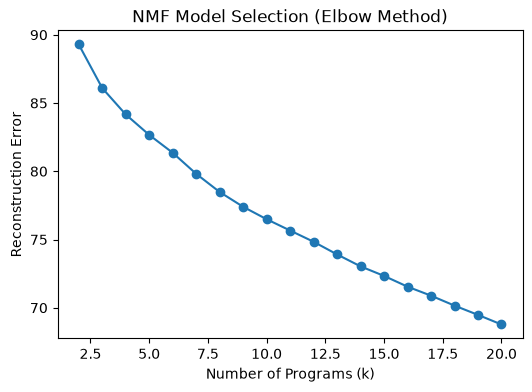

In [11]:
plt.figure(figsize=(6,4))
plt.plot(list(ks), errors, marker="o")
plt.xlabel("Number of Programs (k)")
plt.ylabel("Reconstruction Error")
plt.title("NMF Model Selection (Elbow Method)")
plt.show()

In [12]:
k = 10
n_runs = 20

all_W = []

for seed in range(n_runs):
    nmf = NMF(
        n_components=k,
        init="nndsvda",
        random_state=seed,
        max_iter=1000
    )
    
    W = nmf.fit_transform(X_scaled)
    all_W.append(W)

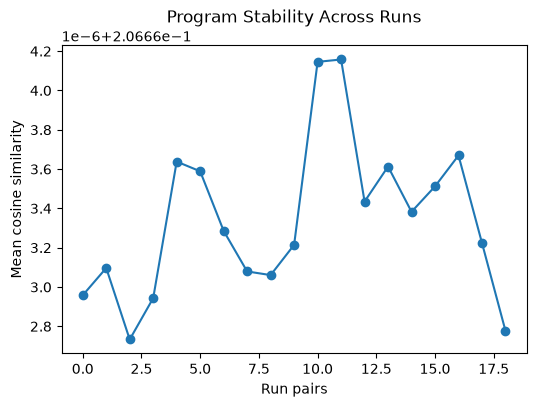

Mean stability: 0.20666334286987306


In [13]:
similarities = []

for i in range(n_runs - 1):
    sim = cosine_similarity(all_W[i].T, all_W[i+1].T)
    similarities.append(np.mean(sim))

plt.figure(figsize=(6,4))
plt.plot(similarities, marker="o")
plt.title("Program Stability Across Runs")
plt.xlabel("Run pairs")
plt.ylabel("Mean cosine similarity")
plt.show()

print("Mean stability:", np.mean(similarities))

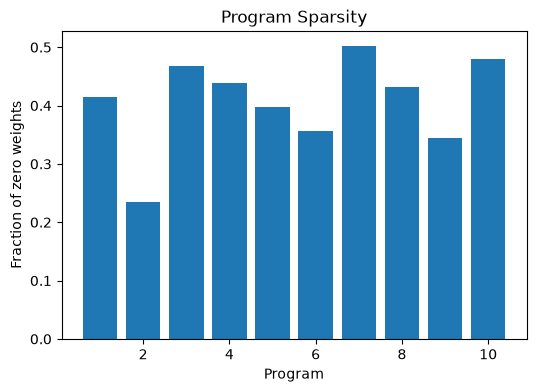

In [14]:
nmf = NMF(n_components=k, init="nndsvda", random_state=42, max_iter=1000)
W = nmf.fit_transform(X_scaled)
H = nmf.components_

H_df = pd.DataFrame(H, columns=X_scaled.columns)

sparsity = (H_df == 0).mean(axis=1)

plt.figure(figsize=(6,4))
plt.bar(range(1, k+1), sparsity)
plt.title("Program Sparsity")
plt.xlabel("Program")
plt.ylabel("Fraction of zero weights")
plt.show()

In [15]:
from sklearn.decomposition import NMF
import numpy as np

k = 10
n_runs = 20
top_features = 20

overlap_scores = []

for i in range(n_runs - 1):

    nmf1 = NMF(
        n_components=k,
        init="nndsvda",
        random_state=i,
        max_iter=1000
    )

    nmf2 = NMF(
        n_components=k,
        init="nndsvda",
        random_state=i + 1,
        max_iter=1000
    )

    nmf1.fit(X_scaled)
    nmf2.fit(X_scaled)

    H1 = nmf1.components_
    H2 = nmf2.components_

    overlap = []

    for p in range(k):

        f1 = set(np.argsort(H1[p])[-top_features:])
        f2 = set(np.argsort(H2[p])[-top_features:])

        overlap.append(len(f1 & f2) / top_features)

    overlap_scores.append(np.mean(overlap))

print(f"Mean feature overlap: {np.mean(overlap_scores):.3f}")

Mean feature overlap: 1.000


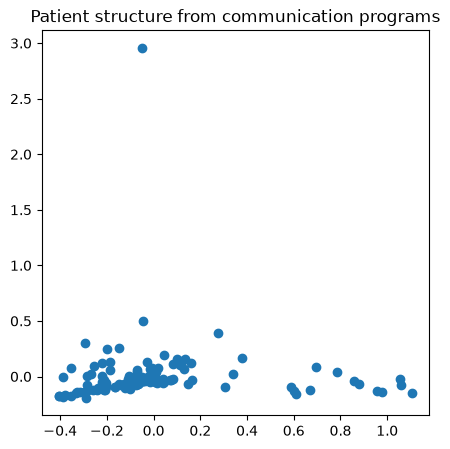

In [16]:
from sklearn.decomposition import PCA

patient_embedding = W

pca = PCA(n_components=2)
X_pca = pca.fit_transform(patient_embedding)

plt.figure(figsize=(5,5))
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("Patient structure from communication programs")
plt.show()

In [17]:
pd.DataFrame(W, index=X.index).to_csv(
    "data/outputs/validated_patient_programs.csv"
)

H_df.to_csv(
    "data/outputs/validated_program_features.csv"
)

print("Saved validated program outputs.")

Saved validated program outputs.


In [18]:
print("="*50)
print("NMF Validation Summary")
print("="*50)

print(f"Patients: {X.shape[0]}")
print(f"Communication features: {X.shape[1]}")
print(f"Programs (k): {k}")
print(f"Reconstruction error: {errors[k-2]:.4f}")
print(f"Mean stability: {np.mean(similarities):.3f}")

print("\nProgram sizes (top features):")
for i in range(k):
    n_nonzero = np.sum(H[i] > 1e-4)
    print(f"Program {i+1}: {n_nonzero} active interactions")

NMF Validation Summary
Patients: 138
Communication features: 3489
Programs (k): 10
Reconstruction error: 76.4870
Mean stability: 0.207

Program sizes (top features):
Program 1: 2023 active interactions
Program 2: 2648 active interactions
Program 3: 1840 active interactions
Program 4: 1940 active interactions
Program 5: 2090 active interactions
Program 6: 2231 active interactions
Program 7: 1713 active interactions
Program 8: 1950 active interactions
Program 9: 2261 active interactions
Program 10: 1793 active interactions


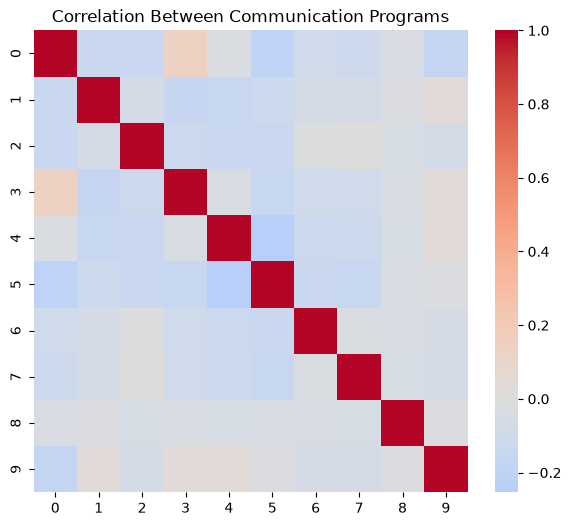

In [19]:
import seaborn as sns

corr = pd.DataFrame(W).corr()

plt.figure(figsize=(7,6))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Communication Programs")
plt.show()